In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
df = pd.read_csv("amazon_sales_2025_INR_cleaned.csv")

df.head()

,Report_Section,Dimension,Metric1,Metric2,Metric3,Metric4
0,AVERAGE_ORDER_VALUE,Overall Statistics,7.454412e+04,204.050003,249955.5,NaN
1,CATEGORY_PERFORMANCE,Beauty,2.274896e+08,2997.000000,NaN,NaN
2,CATEGORY_PERFORMANCE,Electronics,2.265649e+08,3036.000000,NaN,NaN
3,CATEGORY_PERFORMANCE,Books,2.249992e+08,3035.000000,NaN,NaN
4,CATEGORY_PERFORMANCE,Clothing,2.224093e+08,3022.000000,NaN,NaN


In [6]:
df.shape

(189, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Report_Section  189 non-null    object 
 1   Dimension       189 non-null    object 
 2   Metric1         189 non-null    float64
 3   Metric2         189 non-null    float64
 4   Metric3         60 non-null     float64
 5   Metric4         12 non-null     float64
dtypes: float64(4), object(2)
memory usage: 9.0+ KB


In [8]:
df.columns

Index(['Report_Section', 'Dimension', 'Metric1', 'Metric2', 'Metric3',
       'Metric4'],
      dtype='object')

In [9]:
df.dtypes

Report_Section     object
Dimension          object
Metric1           float64
Metric2           float64
Metric3           float64
Metric4           float64
dtype: object

In [10]:
df.head()

,Report_Section,Dimension,Metric1,Metric2,Metric3,Metric4
0,AVERAGE_ORDER_VALUE,Overall Statistics,7.454412e+04,204.050003,249955.5,NaN
1,CATEGORY_PERFORMANCE,Beauty,2.274896e+08,2997.000000,NaN,NaN
2,CATEGORY_PERFORMANCE,Electronics,2.265649e+08,3036.000000,NaN,NaN
3,CATEGORY_PERFORMANCE,Books,2.249992e+08,3035.000000,NaN,NaN
4,CATEGORY_PERFORMANCE,Clothing,2.224093e+08,3022.000000,NaN,NaN


In [11]:
df.tail()

,Report_Section,Dimension,Metric1,Metric2,Metric3,Metric4
184,TOP_SELLING_PRODUCTS,Laptop,4.617387e+07,618.0,NaN,NaN
185,TOP_SELLING_PRODUCTS,Tablet,4.617002e+07,616.0,NaN,NaN
186,TOP_SELLING_PRODUCTS,Sneakers,4.605730e+07,596.0,NaN,NaN
187,TOP_SELLING_PRODUCTS,Air Fryer,4.591971e+07,614.0,NaN,NaN
188,TOP_SELLING_PRODUCTS,Jeans,4.523282e+07,604.0,NaN,NaN


In [13]:
df.describe()

,Metric1,Metric2,Metric3,Metric4
count,1.890000e+02,1.890000e+02,6.000000e+01,12.000000
mean,2.135449e+07,5.630621e+06,5.593367e+07,6.500000
std,4.277835e+07,4.938918e+07,1.493316e+08,3.605551
min,2.000000e+00,2.431000e+01,1.864000e+01,1.000000
25%,6.000000e+00,5.500000e+02,5.120000e+02,3.750000
50%,5.090000e+02,3.035000e+03,5.435000e+02,6.500000
75%,3.934878e+07,4.925239e+05,7.592359e+04,9.250000
max,2.274896e+08,6.619194e+08,8.316504e+08,12.000000


In [14]:
df.isnull().sum()

Report_Section      0
Dimension           0
Metric1             0
Metric2             0
Metric3           129
Metric4           177
dtype: int64

In [15]:
(df.isnull().sum() / len(df)) * 100

Report_Section     0.000000
Dimension          0.000000
Metric1            0.000000
Metric2            0.000000
Metric3           68.253968
Metric4           93.650794
dtype: float64

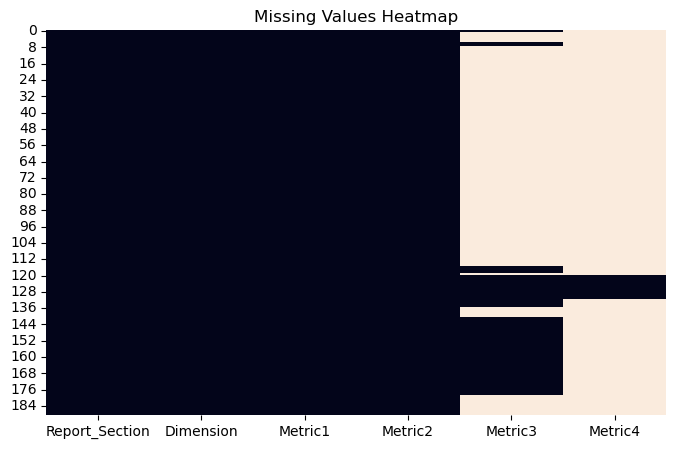

In [16]:
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show() # visualization of missing values

In [20]:
  df.duplicated().sum() ## Check Duplicate Values

np.int64(0)

In [21]:
## Check Unique Report Sections
df["Report_Section"].unique()

array(['AVERAGE_ORDER_VALUE', 'CATEGORY_PERFORMANCE',
       'COD_VS_DIGITAL_PAYMENTS', 'CUSTOMER_COUNT_BY_STATE',
       'CUSTOMER_PURCHASE_FREQUENCY', 'DELIVERY_SUCCESS_RATE',
       'HIGH_VALUE_ORDERS', 'MONTHLY_SALES_TRENDS',
       'PAYMENT_METHOD_PREFERENCES', 'PRODUCT_QUANTITY_DISTRIBUTION',
       'RETURNS_BY_CATEGORY', 'STATE_WISE_SALES',
       'TOP_REVENUE_STATES_2025', 'TOP_SELLING_PRODUCTS'], dtype=object)

In [23]:
df["Report_Section"].value_counts()

Report_Section
CUSTOMER_PURCHASE_FREQUENCY      80
CUSTOMER_COUNT_BY_STATE          28
STATE_WISE_SALES                 28
MONTHLY_SALES_TRENDS             12
TOP_SELLING_PRODUCTS             10
CATEGORY_PERFORMANCE              5
PRODUCT_QUANTITY_DISTRIBUTION     5
RETURNS_BY_CATEGORY               5
TOP_REVENUE_STATES_2025           5
PAYMENT_METHOD_PREFERENCES        4
DELIVERY_SUCCESS_RATE             3
COD_VS_DIGITAL_PAYMENTS           2
AVERAGE_ORDER_VALUE               1
HIGH_VALUE_ORDERS                 1
Name: count, dtype: int64

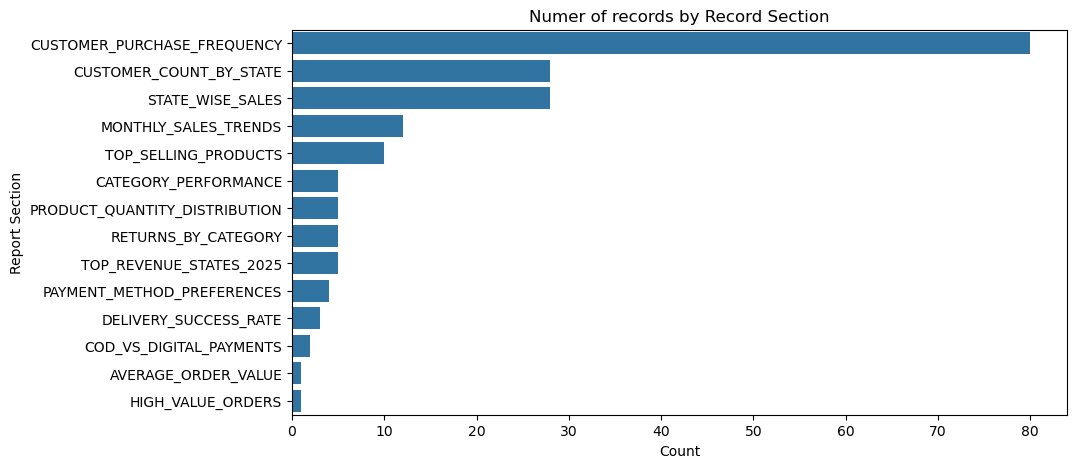

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="Report_Section",
    order=df["Report_Section"].value_counts().index
)
plt.title("Numer of records by Record Section")
plt.xlabel("Count")
plt.ylabel("Report Section")
plt.show()

In [27]:
category_df = df[
    df["Report_Section"] == "CATEGORY_PERFORMANCE"
].copy()
category_df

,Report_Section,Dimension,Metric1,Metric2,Metric3,Metric4
1,CATEGORY_PERFORMANCE,Beauty,2.274896e+08,2997.0,NaN,NaN
2,CATEGORY_PERFORMANCE,Electronics,2.265649e+08,3036.0,NaN,NaN
3,CATEGORY_PERFORMANCE,Books,2.249992e+08,3035.0,NaN,NaN
4,CATEGORY_PERFORMANCE,Clothing,2.224093e+08,3022.0,NaN,NaN
5,CATEGORY_PERFORMANCE,Home & Kitchen,2.166987e+08,2910.0,NaN,NaN


In [28]:
category_df = category_df.sort_values(
    "Metric1",
    ascending=False
)

category_df[["Dimension", "Metric1"]]

,Dimension,Metric1
1,Beauty,2.274896e+08
2,Electronics,2.265649e+08
3,Books,2.249992e+08
4,Clothing,2.224093e+08
5,Home & Kitchen,2.166987e+08


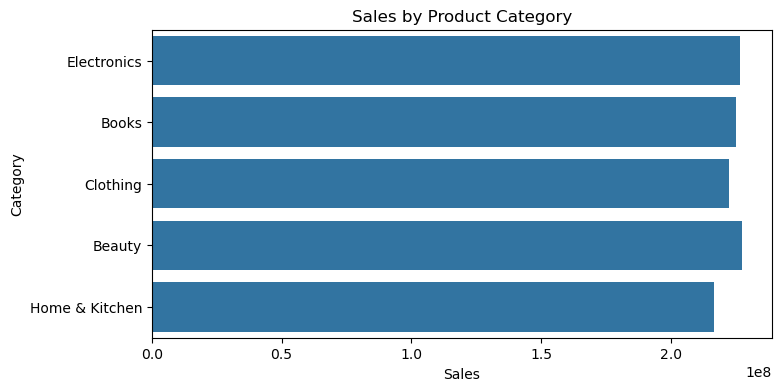

In [37]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=category_df,
    x="Metric1",
    y="Dimension"
)

plt.title("Sales by Product Category")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.show()

In [30]:
top_category = category_df.iloc[0]

print("Top Category:", top_category["Dimension"])
print("Sales:", top_category["Metric1"])

Top Category: Beauty
Sales: 227489624.69540405


In [31]:
category_df = category_df.sort_values(
    "Metric2",
    ascending=False
)

category_df[["Dimension", "Metric2"]]

,Dimension,Metric2
2,Electronics,3036.0
3,Books,3035.0
4,Clothing,3022.0
1,Beauty,2997.0
5,Home & Kitchen,2910.0


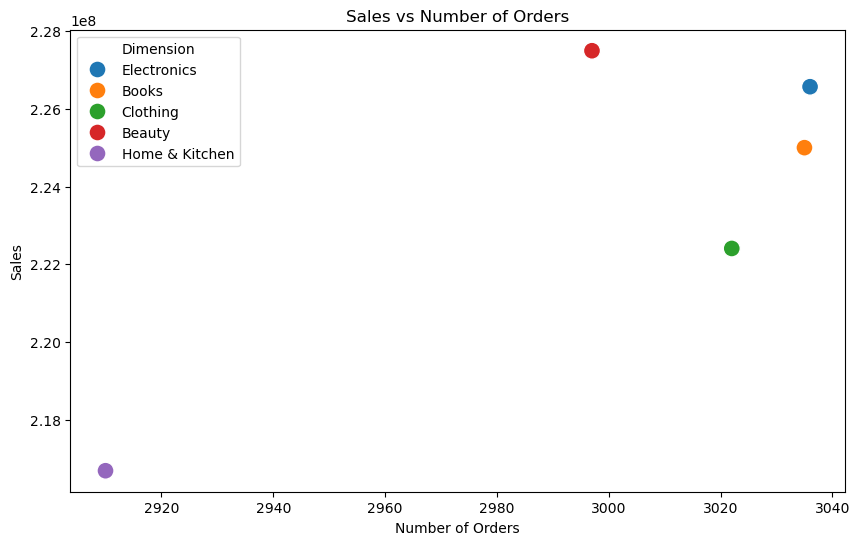

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=category_df,
    x ="Metric2",
    y="Metric1",
    hue="Dimension",
    s=150
)

plt.title("Sales vs Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Sales")

plt.show()

In [33]:
aov_df = df[
    df["Report_Section"] == "AVERAGE_ORDER_VALUE"
].copy()

aov_df ## avrage order value

,Report_Section,Dimension,Metric1,Metric2,Metric3,Metric4
0,AVERAGE_ORDER_VALUE,Overall Statistics,74544.120246,204.050003,249955.5,NaN


In [34]:
aov_df[
    ["Dimension", "Metric1", "Metric2", "Metric3", "Metric4"]
]

,Dimension,Metric1,Metric2,Metric3,Metric4
0,Overall Statistics,74544.120246,204.050003,249955.5,NaN


In [35]:
aov = aov_df.iloc[0]

print("Average Order Value:", aov["Metric1"])

Average Order Value: 74544.12024614868


In [38]:
df["Report_Section"].value_counts()

Report_Section
CUSTOMER_PURCHASE_FREQUENCY      80
CUSTOMER_COUNT_BY_STATE          28
STATE_WISE_SALES                 28
MONTHLY_SALES_TRENDS             12
TOP_SELLING_PRODUCTS             10
CATEGORY_PERFORMANCE              5
PRODUCT_QUANTITY_DISTRIBUTION     5
RETURNS_BY_CATEGORY               5
TOP_REVENUE_STATES_2025           5
PAYMENT_METHOD_PREFERENCES        4
DELIVERY_SUCCESS_RATE             3
COD_VS_DIGITAL_PAYMENTS           2
AVERAGE_ORDER_VALUE               1
HIGH_VALUE_ORDERS                 1
Name: count, dtype: int64

In [39]:
for section in df["Report_Section"].unique():
    print("\n", "="*50)
    print(section)
    print("="*50)
    
    print(df[df["Report_Section"] == section].head())


AVERAGE_ORDER_VALUE
        Report_Section           Dimension       Metric1     Metric2  \
0  AVERAGE_ORDER_VALUE  Overall Statistics  74544.120246  204.050003   

    Metric3  Metric4  
0  249955.5      NaN  

CATEGORY_PERFORMANCE
         Report_Section       Dimension       Metric1  Metric2  Metric3  \
1  CATEGORY_PERFORMANCE          Beauty  2.274896e+08   2997.0      NaN   
2  CATEGORY_PERFORMANCE     Electronics  2.265649e+08   3036.0      NaN   
3  CATEGORY_PERFORMANCE           Books  2.249992e+08   3035.0      NaN   
4  CATEGORY_PERFORMANCE        Clothing  2.224093e+08   3022.0      NaN   
5  CATEGORY_PERFORMANCE  Home & Kitchen  2.166987e+08   2910.0      NaN   

   Metric4  
1      NaN  
2      NaN  
3      NaN  
4      NaN  
5      NaN  

COD_VS_DIGITAL_PAYMENTS
            Report_Section         Dimension       Metric1  Metric2  \
6  COD_VS_DIGITAL_PAYMENTS  Cash on Delivery  74865.799469   3827.0   
7  COD_VS_DIGITAL_PAYMENTS  Digital Payments  74433.937987  11173.0   

In [44]:
top_categories = (
    category_df
    .sort_values("Metric1", ascending=False)
    .head(10)
)

top_categories[["Dimension", "Metric1"]]

,Dimension,Metric1
1,Beauty,2.274896e+08
2,Electronics,2.265649e+08
3,Books,2.249992e+08
4,Clothing,2.224093e+08
5,Home & Kitchen,2.166987e+08


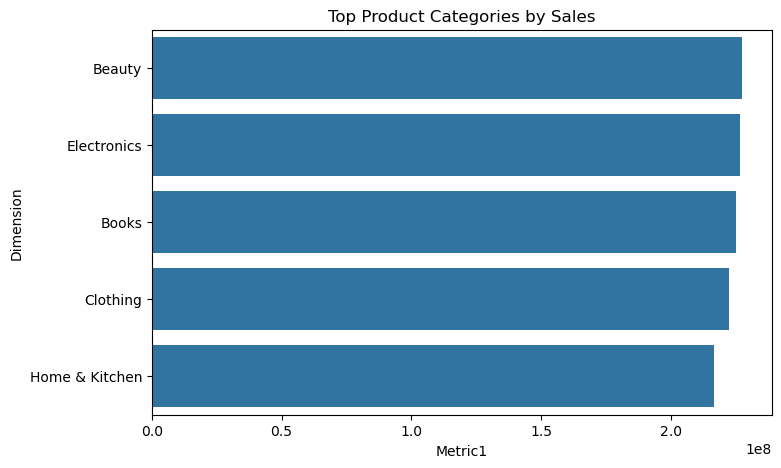

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_categories,
    x="Metric1",
    y="Dimension"
)

plt.title("Top Product Categories by Sales")

plt.show()

In [48]:
category_df["Sales_Percentage"] = (
    category_df["Metric1"] /
    category_df["Metric1"].sum()
) * 100

In [49]:
category_df[
    ["Dimension", "Metric1", "Sales_Percentage"]
]

,Dimension,Metric1,Sales_Percentage
2,Electronics,2.265649e+08,20.262266
3,Books,2.249992e+08,20.122242
4,Clothing,2.224093e+08,19.890622
1,Beauty,2.274896e+08,20.344965
5,Home & Kitchen,2.166987e+08,19.379905


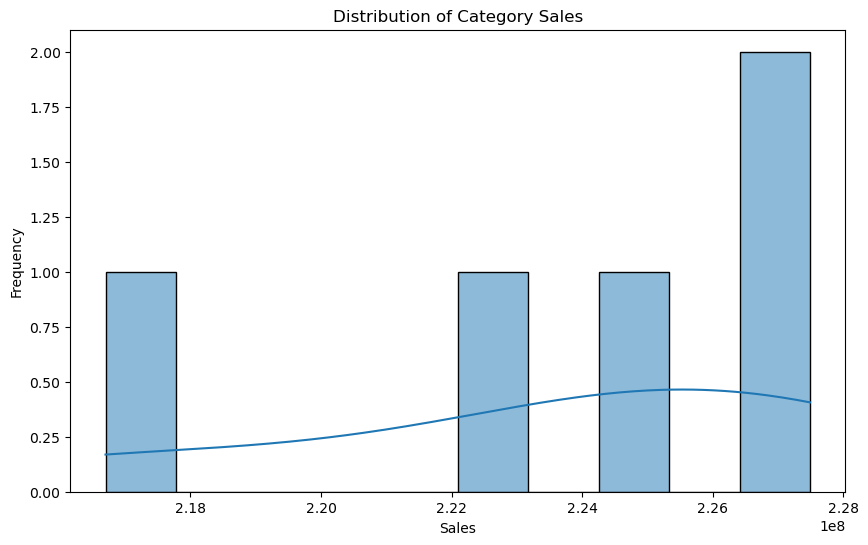

In [50]:
plt.figure(figsize=(10,6))

sns.histplot(
    category_df["Metric1"],
    bins=10,
    kde=True
)

plt.title("Distribution of Category Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

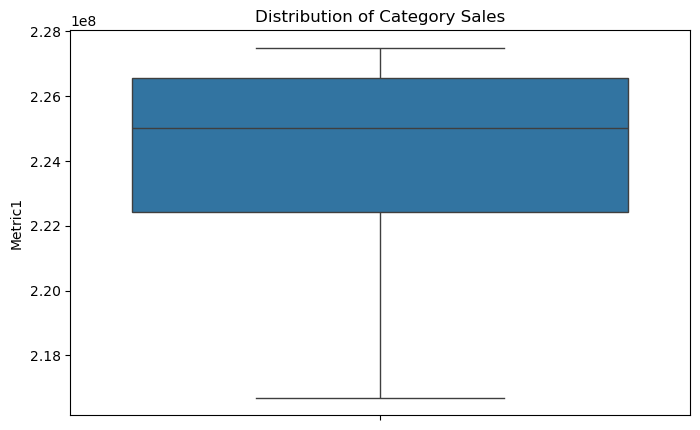

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=category_df["Metric1"]
)

plt.title("Distribution of Category Sales")

plt.show()

In [52]:
numeric_df = df.select_dtypes(
    include=np.number
)

In [53]:
numeric_df.corr()

,Metric1,Metric2,Metric3,Metric4
Metric1,1.000000,-0.057190,-0.494747,0.538534
Metric2,-0.057190,1.000000,-0.113755,0.331095
Metric3,-0.494747,-0.113755,1.000000,0.413205
Metric4,0.538534,0.331095,0.413205,1.000000


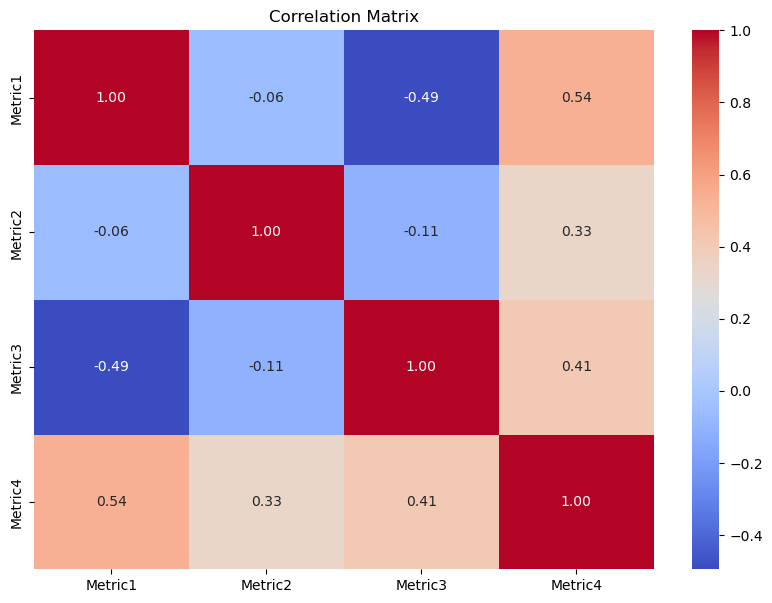

In [54]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [55]:
summary = category_df[
    ["Dimension", "Metric1", "Metric2"]
].copy()

summary.columns = [
    "Category",
    "Sales",
    "Orders"
]

summary

,Category,Sales,Orders
2,Electronics,2.265649e+08,3036.0
3,Books,2.249992e+08,3035.0
4,Clothing,2.224093e+08,3022.0
1,Beauty,2.274896e+08,2997.0
5,Home & Kitchen,2.166987e+08,2910.0


In [56]:
summary["Sales_Per_Order"] = (
    summary["Sales"] /
    summary["Orders"]
)

In [57]:
summary.sort_values(
    "Sales_Per_Order",
    ascending=False
)

,Category,Sales,Orders,Sales_Per_Order
1,Beauty,2.274896e+08,2997.0,75905.780679
2,Electronics,2.265649e+08,3036.0,74626.127557
5,Home & Kitchen,2.166987e+08,2910.0,74466.904807
3,Books,2.249992e+08,3035.0,74134.835853
4,Clothing,2.224093e+08,3022.0,73596.735914


In [58]:
top_value_category = summary.loc[
    summary["Sales_Per_Order"].idxmax()
]

print(
    "Highest Sales per Order:",
    top_value_category["Category"]
)

print(
    "Sales per Order:",
    top_value_category["Sales_Per_Order"]
)

Highest Sales per Order: Beauty
Sales per Order: 75905.78067914717


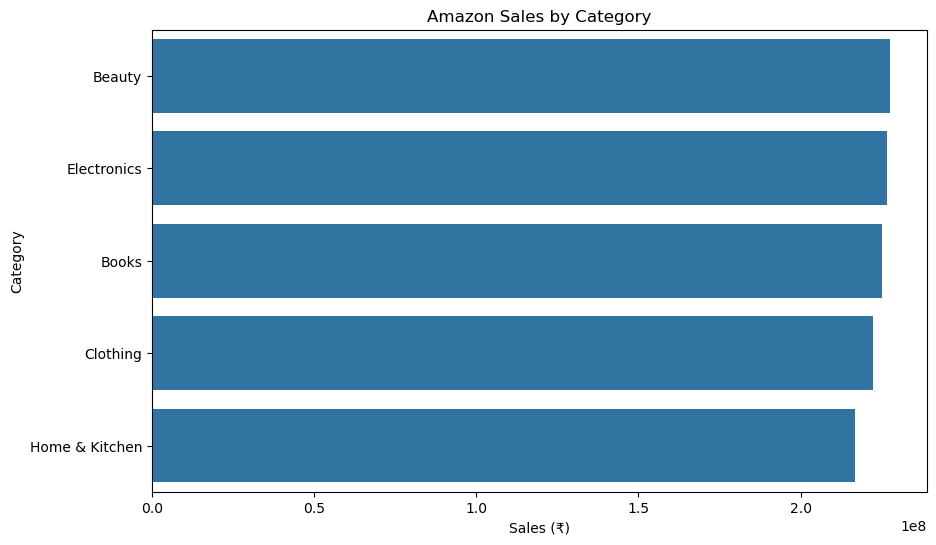

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=summary.sort_values(
        "Sales",
        ascending=False
    ),
    x="Sales",
    y="Category"
)

plt.title("Amazon Sales by Category")
plt.xlabel("Sales (₹)")
plt.ylabel("Category")

plt.show()